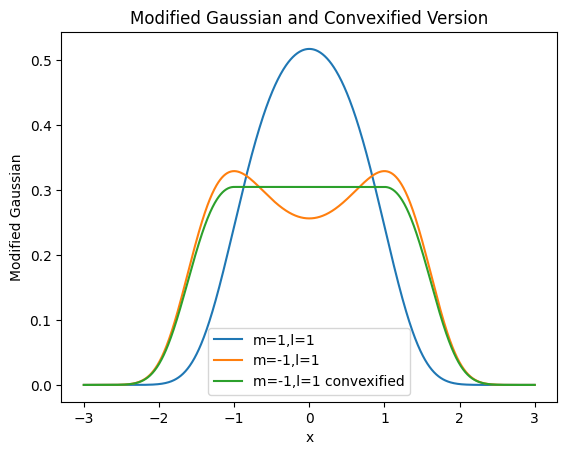

Moment 2 (m=1,l=1): 0.4679199169736833
Moment 2 (m=-1,l=1): 1.041797296486382
Moment 2 convexified (m=-1,l=1): 0.9756617420646575
Moment 4 (m=1,l=1): 0.5320800830264818
Moment 4 (m=-1,l=1): 2.041797296485639
Moment 4 convexified (m=-1,l=1): 1.8944667909056387


In [10]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

class ModifiedGaussian:

    def __init__(self, m, l):
        self.m = m
        self.l = l
        # compute normalization constant
        self.norm = quad(self._modified_gaussian, -np.inf, np.inf)[0]
        self.norm_convex = quad(self._convexify_modified_gaussian, -np.inf, np.inf)[0]

    def _modified_gaussian(self, x):
        return np.exp(
            -0.5*self.m*x**2 - 0.25*self.l*x**4
        )
    
    def modified_gaussian(self, x):
        return self._modified_gaussian(x) / self.norm
    
    def _convexify_modified_gaussian(self, x):
        """ if m<0, convexify the modified gaussian by taking its negative and shifting it up """
        x = np.array(x)
        if self.m < 0:
            # x takes maximum at 
            x_convex = np.sqrt(-self.m/self.l)
            x[np.abs(x) < x_convex] = x_convex
        return self._modified_gaussian(x)

    def convexify_modified_gaussian(self, x):
        return self._convexify_modified_gaussian(x) / self.norm_convex 

    def moment(self, n):
        """ compute the n-th moment of the modified gaussian """
        func = lambda x: x**n * self.modified_gaussian(x)
        moment, _ = quad(func, -np.inf, np.inf)
        return moment
    
    def moment_convex(self, n):
        """ compute the n-th moment of the convexified modified gaussian """
        func = lambda x: x**n * self.convexify_modified_gaussian(x)
        moment, _ = quad(func, -np.inf, np.inf)
        return moment


def _modified_gaussian(x,m,l):
    return np.exp(
        -0.5*m*x**2 - 0.25*l*x**4
    )

def _convexify_modified_gaussian(x,m,l):
    """ if m<0, convexify the modified gaussian by taking its negative and shifting it up """
    x = x.copy()
    if m < 0:
        # x takes maximum at 
        x_convex = np.sqrt(-m/l)
        x[np.abs(x) < x_convex] = x_convex
    return modified_gaussian(x,m,l)

x = np.linspace(-3,3,1000)
gauss = ModifiedGaussian(1,1)
y1 = gauss.modified_gaussian(x)
neg_gauss = ModifiedGaussian(-1,1)
y2 = neg_gauss.modified_gaussian(x)
y2_convex = neg_gauss.convexify_modified_gaussian(x)
plt.plot(x,y1,label='m=1,l=1')
plt.plot(x,y2,label='m=-1,l=1')
plt.plot(x,y2_convex,label='m=-1,l=1 convexified')
plt.legend()
plt.xlabel('x')
plt.ylabel('Modified Gaussian')
plt.title('Modified Gaussian and Convexified Version')
plt.show()
# moments
for n in range(2,5,2):
    print(f"Moment {n} (m=1,l=1): {gauss.moment(n)}")
    print(f"Moment {n} (m=-1,l=1): {neg_gauss.moment(n)}")
    print(f"Moment {n} convexified (m=-1,l=1): {neg_gauss.moment_convex(n)}")